## 1. Import library dan memuat data
Library untuk EDA, preprocessing, clustering, evaluasi, dan PCA disiapkan. Pastikan CSV tersedia pada folder kerja Colab.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style="whitegrid")

# Cari folder proyek, baik kernel berjalan dari
# folder utama maupun folder notebooks
current_dir = Path.cwd().resolve()
filename = "semiconductor_wafer_defect_dataset.csv"

csv_path = None

for folder in [current_dir, *current_dir.parents]:
    candidate = folder / "data" / filename
    if candidate.is_file():
        csv_path = candidate
        project_root = folder
        break

if csv_path is None:
    raise FileNotFoundError(
        f"File {filename} belum ditemukan di folder data. "
        "Pastikan folder data sejajar dengan folder notebooks."
    )

# Baca dataset
df = pd.read_csv(csv_path)

sensor_cols = [
    "temperature_c",
    "pressure_torr",
    "gas_flow_sccm",
    "etch_rate_nm_min",
    "voltage_v",
    "current_ma"
]

# Periksa kolom yang diperlukan
required_cols = sensor_cols + ["process_step"]
missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(f"Kolom dataset belum sesuai: {missing_cols}")

print("Lokasi dataset:", csv_path)
print("Ukuran data:", df.shape)
display(df.head())

Lokasi dataset: F:\S1 [ Politeknik Manufaktur Bandung - Teknik Rekayasa Informatika Industri ]\SMT 5\Praktek\MLN\minggu 2\wafer_defect\wafer-defect-classification\data\semiconductor_wafer_defect_dataset.csv
Ukuran data: (5000, 9)


,wafer_id,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma,process_step,defect_label
0,1,457.450712,747.287210,113.215053,93.852614,5.139314,20.341747,Deposition,0
1,2,447.926035,746.397577,116.945005,94.738753,5.113329,20.024511,Lithography,0
2,3,459.715328,706.130705,114.026189,95.514359,4.625392,19.137690,Deposition,0
3,4,472.845448,750.097294,121.104180,102.574892,5.231834,19.994947,Deposition,0
4,5,446.487699,781.984872,131.971785,89.022262,4.403967,20.981683,Deposition,0


## 2. EDA singkat
Periksa tipe data, nilai kosong, duplikat, distribusi kategori proses, dan statistik sensor. `defect_label` boleh diringkas untuk memahami dataset, tetapi tidak dipakai dalam pelatihan.

In [7]:
df.info()
print('Missing value per kolom:')
display(df.isna().sum().to_frame('Jumlah'))
print('Duplikat:', df.duplicated().sum())
display(df.describe(include='all').T)
print('Distribusi process_step:')
display(df['process_step'].value_counts())
print('Distribusi defect_label (hanya informasi tambahan):')
display(df['defect_label'].value_counts())


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wafer_id          5000 non-null   int64  
 1   temperature_c     5000 non-null   float64
 2   pressure_torr     5000 non-null   float64
 3   gas_flow_sccm     5000 non-null   float64
 4   etch_rate_nm_min  5000 non-null   float64
 5   voltage_v         5000 non-null   float64
 6   current_ma        5000 non-null   float64
 7   process_step      5000 non-null   str    
 8   defect_label      5000 non-null   int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 390.5 KB
Missing value per kolom:


,Jumlah
wafer_id,0
temperature_c,0
pressure_torr,0
gas_flow_sccm,0
etch_rate_nm_min,0
voltage_v,0
current_ma,0
process_step,0
defect_label,0


Duplikat: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
wafer_id,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
temperature_c,5000.0,NaN,NaN,NaN,450.084029,14.947197,401.38099,440.131424,450.201984,459.990159,508.893566
pressure_torr,5000.0,NaN,NaN,NaN,759.703783,30.313113,642.327992,739.402513,759.476484,780.317142,865.871656
gas_flow_sccm,5000.0,NaN,NaN,NaN,120.10553,9.987698,86.244209,113.391136,120.099174,126.755342,154.289105
etch_rate_nm_min,5000.0,NaN,NaN,NaN,95.132121,8.026693,64.148997,89.682554,95.154073,100.652917,130.832674
voltage_v,5000.0,NaN,NaN,NaN,4.992659,0.39335,3.537965,4.719296,4.996793,5.260243,6.44454
current_ma,5000.0,NaN,NaN,NaN,19.986853,1.998921,13.093292,18.601549,19.997914,21.354883,27.383249
process_step,5000,5,CMP,1029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
defect_label,5000.0,NaN,NaN,NaN,0.0014,0.037394,0.0,0.0,0.0,0.0,1.0


Distribusi process_step:


process_step
CMP            1029
Oxidation      1027
Etching         997
Lithography     992
Deposition      955
Name: count, dtype: int64

Distribusi defect_label (hanya informasi tambahan):


defect_label
0    4993
1       7
Name: count, dtype: int64

## 3. Visualisasi EDA
Tiga visualisasi pertama menunjukkan proses manufaktur, distribusi sensor, serta hubungan antar sensor. Perhatikan pola yang dapat membedakan kondisi proses.

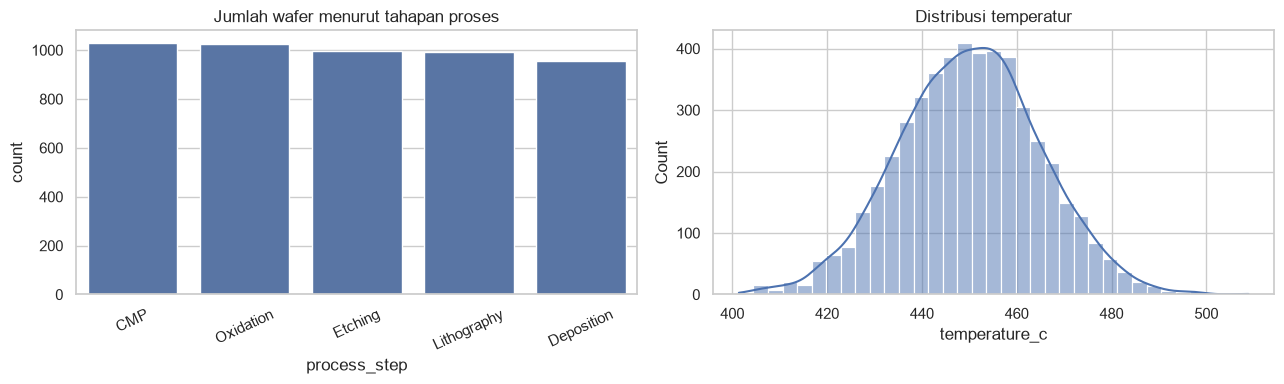

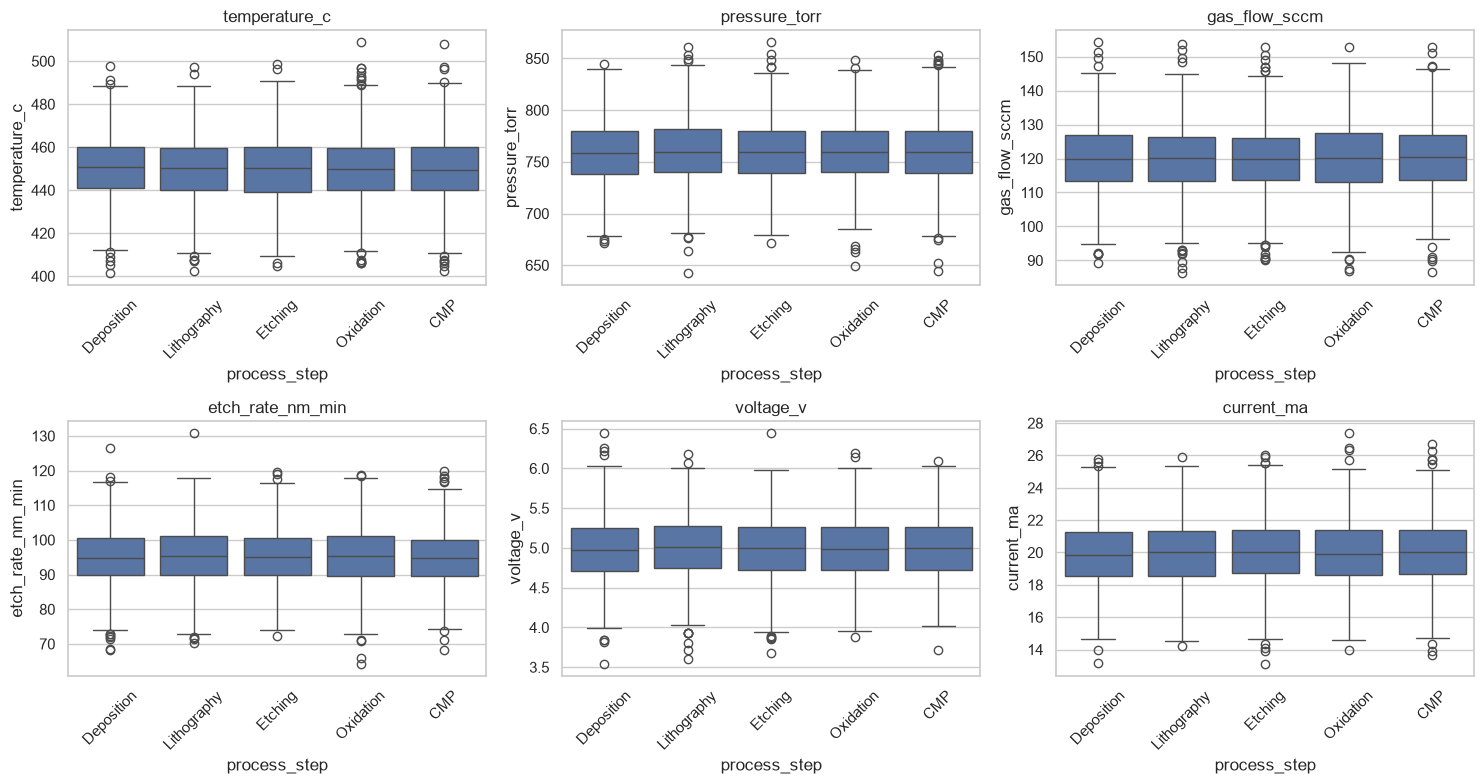

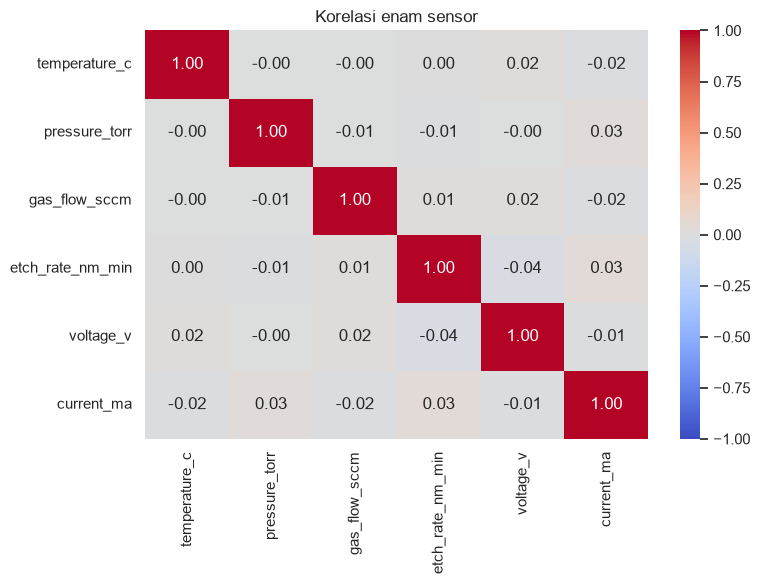

In [12]:
sensor_cols = ['temperature_c', 'pressure_torr', 'gas_flow_sccm',
               'etch_rate_nm_min', 'voltage_v', 'current_ma']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='process_step', order=df['process_step'].value_counts().index, ax=axes[0])
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_title('Jumlah wafer menurut tahapan proses')
sns.histplot(data=df, x='temperature_c', bins=35, kde=True, ax=axes[1])
axes[1].set_title('Distribusi temperatur')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, sensor_cols):
    sns.boxplot(data=df, x='process_step', y=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)
    ax.set_title(col)
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df[sensor_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Korelasi enam sensor'); plt.tight_layout(); plt.show()


## 4. Preprocessing
ID dan label defect dikeluarkan. Nilai kosong numerik diisi dengan median bila ada; kategori diisi modus dan diubah menjadi one-hot. Seluruh fitur kemudian distandardisasi agar jarak antar wafer dapat dibandingkan.

In [16]:
X_raw = df[sensor_cols + ['process_step']].copy()
preprocessor = ColumnTransformer([
    ('sensor', Pipeline([('imputer', SimpleImputer(strategy='median'))]), sensor_cols),
    ('step', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                       ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), ['process_step'])
], verbose_feature_names_out=False)
X_prepared = preprocessor.fit_transform(X_raw)
feature_names = preprocessor.get_feature_names_out()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prepared)
print('Ukuran matriks fitur:', X_scaled.shape)
print('Fitur:', list(feature_names))


Ukuran matriks fitur: (5000, 11)
Fitur: ['temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step_CMP', 'process_step_Deposition', 'process_step_Etching', 'process_step_Lithography', 'process_step_Oxidation']


## 5. Menentukan K untuk K-Means
Elbow menggunakan inertia, sedangkan Silhouette mengukur keterpisahan cluster. Skor dihitung pada sampel tetap agar komputasi tidak terlalu berat. Pilih K berdasarkan keduanya; pilihan awal otomatis menggunakan Silhouette tertinggi.

,K,Inertia,Silhouette
0,2,48708.7660,0.1267
1,3,42434.2139,0.1886
2,4,36198.0943,0.2533
3,5,29982.9635,0.3191
4,6,29214.6519,0.2682
5,7,28476.3161,0.2323
6,8,27762.1174,0.1910


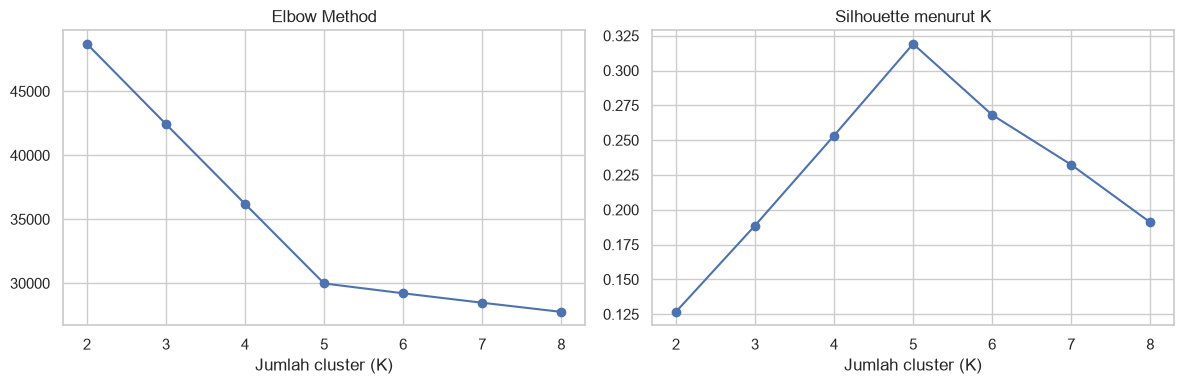

K awal berdasarkan Silhouette: 5


In [19]:
k_values = range(2, 9)
elbow_rows = []
for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    elbow_rows.append({'K': k, 'Inertia': km.inertia_,
                       'Silhouette': silhouette_score(X_scaled, labels, sample_size=1500, random_state=42)})
elbow_df = pd.DataFrame(elbow_rows)
display(elbow_df.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(elbow_df['K'], elbow_df['Inertia'], 'o-'); axes[0].set_title('Elbow Method')
axes[1].plot(elbow_df['K'], elbow_df['Silhouette'], 'o-'); axes[1].set_title('Silhouette menurut K')
for ax in axes: ax.set_xlabel('Jumlah cluster (K)')
plt.tight_layout(); plt.show()
k_optimal = int(elbow_df.loc[elbow_df['Silhouette'].idxmax(), 'K'])
print('K awal berdasarkan Silhouette:', k_optimal)
# Bila titik siku pada grafik menyarankan K lain, ubah k_optimal secara manual dan jelaskan alasannya.


### 5. PREPOCESSING DBSCAN
Data dipersiapkan dengan menghapus kolom yang tidak digunakan, melakukan encoding pada `process_step`, dan standardisasi fitur.

In [21]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('/content/sample_data/semiconductor_wafer_defect_dataset.csv')

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['wafer_id', 'defect_label']]

df_clean = df.drop(['wafer_id', 'defect_label'], axis=1).copy()

le = LabelEncoder()
df_clean['process_step_encoded'] = le.fit_transform(df_clean['process_step'])

clustering_features = numerical_cols + ['process_step_encoded']

X = df_clean[clustering_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Jumlah data:", X_scaled.shape[0])
print("Jumlah fitur:", X_scaled.shape[1])
print("Fitur yang digunakan:")
print(clustering_features)

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/semiconductor_wafer_defect_dataset.csv'

### 6. Menentukan eps dan min_samples

Beberapa kombinasi `eps` dan `min_samples` diuji untuk mendapatkan hasil clustering yang sesuai.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

kombinasi = [
    (1.0, 5),
    (1.2, 5),
    (1.4, 3),
    (1.5, 3),
    (1.6, 3),
    (1.7, 3),
    (1.8, 3)
]

hasil_dbscan = []

for eps, min_samples in kombinasi:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    jumlah_cluster = len(set(labels)) - (1 if -1 in labels else 0)
    jumlah_noise = np.sum(labels == -1)
    noise_percent = (jumlah_noise / len(labels)) * 100

    mask = labels != -1

    if jumlah_cluster >= 2 and mask.sum() > jumlah_cluster:
        silhouette = silhouette_score(X_scaled[mask], labels[mask])
        davies = davies_bouldin_score(X_scaled[mask], labels[mask])
        calinski = calinski_harabasz_score(X_scaled[mask], labels[mask])
    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    hasil_dbscan.append({
        'eps': eps,
        'min_samples': min_samples,
        'Jumlah Cluster': jumlah_cluster,
        'Noise (%)': round(noise_percent, 2),
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies,
        'Calinski-Harabasz Index': calinski
    })

hasil_dbscan = pd.DataFrame(hasil_dbscan)

hasil_dbscan.round(4)

,eps,min_samples,Jumlah Cluster,Noise (%),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,1.0,5,20,51.72,-0.2851,1.1672,6.3429
1,1.2,5,4,21.18,-0.0183,0.9610,5.7312
2,1.4,3,7,5.88,-0.0062,0.9031,6.3577
3,1.5,3,3,3.64,0.1475,0.9171,6.5566
4,1.6,3,2,1.84,0.2501,0.8023,7.5688
5,1.7,3,2,1.14,0.2479,0.8046,7.5030
6,1.8,3,2,0.72,0.2466,0.8058,7.4635


### 7. Hasil Percobaan

Hasil setiap kombinasi dibandingkan berdasarkan jumlah cluster, noise, dan nilai evaluasi clustering.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

kombinasi = [
    (1.0, 5),
    (1.2, 5),
    (1.4, 3),
    (1.5, 3),
    (1.6, 3),
    (1.7, 3),
    (1.8, 3)
]

hasil_dbscan = []

for eps, min_samples in kombinasi:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    jumlah_cluster = len(set(labels)) - (1 if -1 in labels else 0)
    jumlah_noise = np.sum(labels == -1)
    noise_percent = (jumlah_noise / len(labels)) * 100

    mask = labels != -1

    if jumlah_cluster >= 2 and mask.sum() > jumlah_cluster:
        silhouette = silhouette_score(X_scaled[mask], labels[mask])
        davies = davies_bouldin_score(X_scaled[mask], labels[mask])
        calinski = calinski_harabasz_score(X_scaled[mask], labels[mask])
    else:
        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    hasil_dbscan.append({
        'eps': eps,
        'min_samples': min_samples,
        'Jumlah Cluster': jumlah_cluster,
        'Noise (%)': round(noise_percent, 2),
        'Silhouette Score': silhouette,
        'Davies-Bouldin Index': davies,
        'Calinski-Harabasz Index': calinski
    })

hasil_dbscan = pd.DataFrame(hasil_dbscan)

hasil_dbscan.round(4)

,eps,min_samples,Jumlah Cluster,Noise (%),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,1.0,5,20,51.72,-0.2851,1.1672,6.3429
1,1.2,5,4,21.18,-0.0183,0.9610,5.7312
2,1.4,3,7,5.88,-0.0062,0.9031,6.3577
3,1.5,3,3,3.64,0.1475,0.9171,6.5566
4,1.6,3,2,1.84,0.2501,0.8023,7.5688
5,1.7,3,2,1.14,0.2479,0.8046,7.5030
6,1.8,3,2,0.72,0.2466,0.8058,7.4635


### 8. Training DBSCAN

DBSCAN dijalankan menggunakan parameter yang telah dipilih dari hasil percobaan sebelumnya.

In [ ]:
best_eps = 1.6
best_min_samples = 3

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

labels_dbscan = dbscan.fit_predict(X_scaled)

jumlah_cluster = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
jumlah_noise = np.sum(labels_dbscan == -1)
noise_percent = (jumlah_noise / len(labels_dbscan)) * 100

print("Parameter DBSCAN")
print("eps =", best_eps)
print("min_samples =", best_min_samples)
print("Jumlah Cluster =", jumlah_cluster)
print("Jumlah Noise =", jumlah_noise)
print("Persentase Noise =", round(noise_percent, 2), "%")

Parameter DBSCAN
eps = 1.6
min_samples = 3
Jumlah Cluster = 2
Jumlah Noise = 92
Persentase Noise = 1.84 %


### 9. Visualisasi DBSCAN

Hasil clustering divisualisasikan menggunakan PCA 2 dimensi untuk melihat persebaran cluster dan noise.

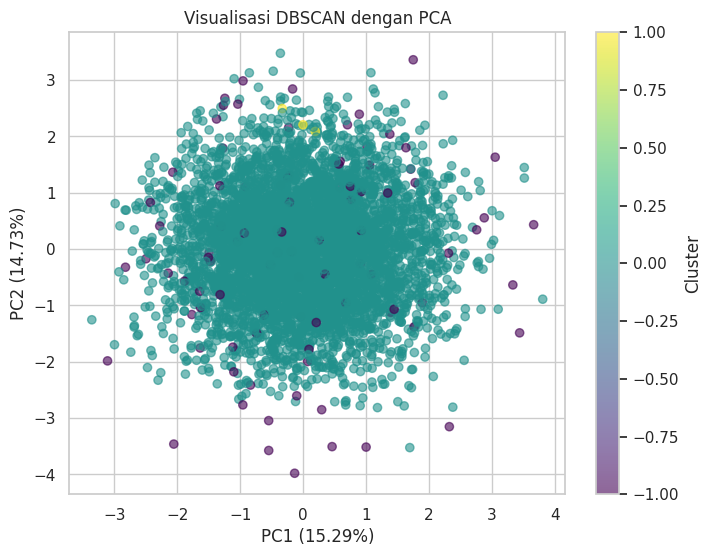

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_dbscan,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)')
plt.title('Visualisasi DBSCAN dengan PCA')
plt.colorbar(scatter, label='Cluster')

plt.show()

### 9. Interpretasi Hasil


Berdasarkan hasil clustering menggunakan DBSCAN dengan `eps = 1.6` dan `min_samples = 3`, data terbagi menjadi 2 cluster dan sebagian kecil data dianggap sebagai noise. Persentase noise yang dihasilkan adalah sekitar 1,84%, sehingga sebagian besar data berhasil dimasukkan ke dalam cluster.

Nilai Silhouette Score yang diperoleh adalah sekitar 0,2501. Nilai ini menunjukkan bahwa pemisahan antar cluster masih belum terlalu kuat, tetapi terdapat pola pengelompokan yang dapat ditemukan dari data.

Nilai Davies-Bouldin Index sebesar sekitar 0,8023 menunjukkan adanya tingkat kemiripan antar cluster yang masih dapat diperbaiki. Sementara itu, nilai Calinski-Harabasz Index yang diperoleh adalah sekitar 7,5688.

Pada visualisasi PCA, data terlihat terbagi menjadi beberapa kelompok berdasarkan hasil DBSCAN. Data yang memiliki label -1 merupakan noise. Secara keseluruhan, DBSCAN berhasil menemukan dua kelompok utama pada data dengan jumlah noise yang relatif kecil, meskipun pemisahan antar cluster belum terlalu jelas.

## 10. Agglomerative Clustering

Agglomerative Clustering mengelompokkan data secara hierarki dengan menggabungkan cluster yang memiliki jarak terdekat. Jumlah cluster menggunakan `k_optimal` dari tahap K-Means dan metode yang digunakan adalah `Ward linkage`.

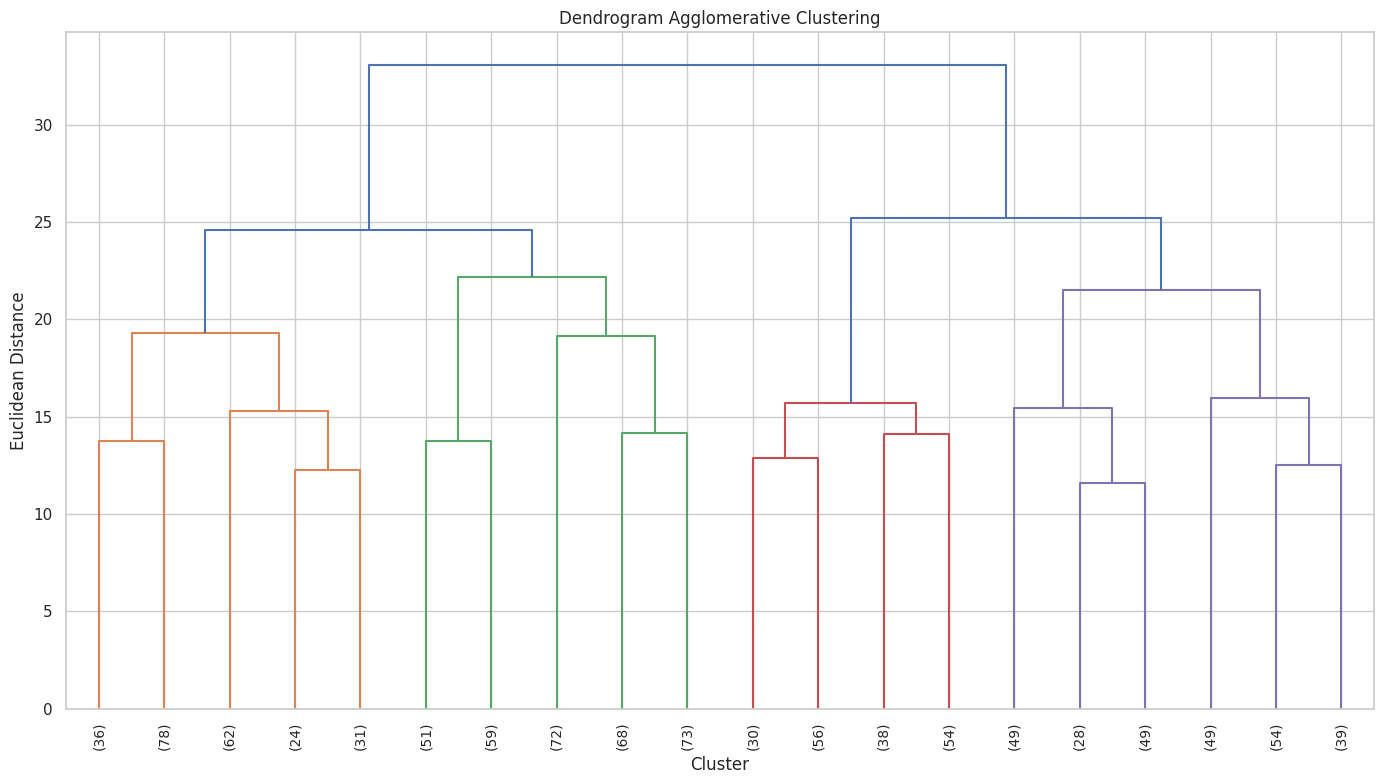

Jumlah Cluster: 5
Distribusi Cluster:
cluster_agg
0    1555
1    1694
2     707
3     606
4     438
Name: count, dtype: int64


In [ ]:
# Dendrogram dan training Agglomerative Clustering

sample_size = min(1000, len(X_scaled))
rng = np.random.default_rng(42)
indices = rng.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[indices]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 8))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=20,
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title('Dendrogram Agglomerative Clustering')
plt.xlabel('Cluster')
plt.ylabel('Euclidean Distance')
plt.tight_layout()
plt.show()

# Model Agglomerative
agg = AgglomerativeClustering(
    n_clusters=k_optimal,
    linkage='ward'
)

agg_labels = agg.fit_predict(X_scaled)
df_clean['cluster_agg'] = agg_labels

print('Jumlah Cluster:', k_optimal)
print('Distribusi Cluster:')
print(df_clean['cluster_agg'].value_counts().sort_index())

## 11. Evaluasi Agglomerative Clustering

Evaluasi dilakukan menggunakan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index untuk mengetahui kualitas hasil clustering.

In [ ]:
# Evaluasi Agglomerative Clustering

sil_agg = silhouette_score(X_scaled, agg_labels)
db_agg = davies_bouldin_score(X_scaled, agg_labels)
ch_agg = calinski_harabasz_score(X_scaled, agg_labels)

print(f"Silhouette Score        : {sil_agg:.4f}")
print(f"Davies-Bouldin Index    : {db_agg:.4f}")
print(f"Calinski-Harabasz Index : {ch_agg:.2f}")

Silhouette Score        : 0.0277
Davies-Bouldin Index    : 2.8378
Calinski-Harabasz Index : 248.46


## 12. Visualisasi Hasil Agglomerative Clustering

Hasil Agglomerative Clustering divisualisasikan menggunakan dua komponen utama PCA untuk melihat persebaran setiap cluster.

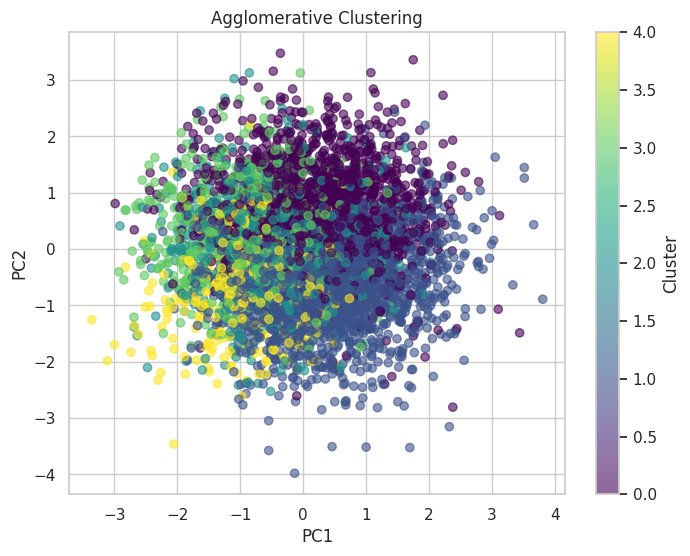

In [ ]:
# PCA untuk visualisasi

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=agg_labels,
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Agglomerative Clustering')
plt.colorbar(label='Cluster')

plt.show()

## 13. Profil Cluster Agglomerative

Profil cluster digunakan untuk melihat karakteristik rata-rata setiap cluster berdasarkan fitur yang digunakan dalam proses clustering.

In [ ]:
# Profil Cluster

cluster_profile_agg = df_clean.groupby('cluster_agg')[clustering_features].mean()

display(cluster_profile_agg.round(3))

,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma,process_step_encoded
cluster_agg,,,,,,,
0,452.177,750.368,121.035,99.268,4.929,19.774,2.754
1,445.353,776.149,118.039,93.962,4.906,20.784,1.673
2,445.660,734.521,117.313,94.822,5.006,19.331,0.760
3,455.479,765.744,132.053,93.314,5.232,19.580,2.165
4,460.627,761.534,112.778,87.989,5.198,19.285,2.438


## 14. Perbandingan Algoritma Clustering

Hasil ketiga algoritma clustering dibandingkan menggunakan Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index.

In [ ]:
# K-Means

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)


# Evaluasi K-Means

sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)


# Evaluasi Agglomerative

sil_agg = silhouette_score(X_scaled, agg_labels)
db_agg = davies_bouldin_score(X_scaled, agg_labels)
ch_agg = calinski_harabasz_score(X_scaled, agg_labels)


# Evaluasi DBSCAN

sil_db = silhouette_score(X_scaled, labels_dbscan)
db_db = davies_bouldin_score(X_scaled, labels_dbscan)
ch_db = calinski_harabasz_score(X_scaled, labels_dbscan)


# Tabel Perbandingan

comparison_df = pd.DataFrame({
    'Algoritma': [
        'K-Means',
        'Agglomerative',
        'DBSCAN'
    ],
    'Silhouette Score': [
        sil_kmeans,
        sil_agg,
        sil_db
    ],
    'Davies-Bouldin Index': [
        db_kmeans,
        db_agg,
        db_db
    ],
    'Calinski-Harabasz Index': [
        ch_kmeans,
        ch_agg,
        ch_db
    ]
})

display(comparison_df.round(4))

,Algoritma,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.0972,2.4671,521.8684
1,Agglomerative,0.0277,2.8378,248.4627
2,DBSCAN,0.1937,11.0317,4.8024


## 15. PCA Analysis dan Visualisasi Cluster

PCA digunakan untuk mengurangi dimensi data sehingga hasil clustering dapat divisualisasikan dalam bentuk 2 dimensi.

Jumlah principal component ditentukan berdasarkan cumulative explained variance dengan target lebih dari 80%.

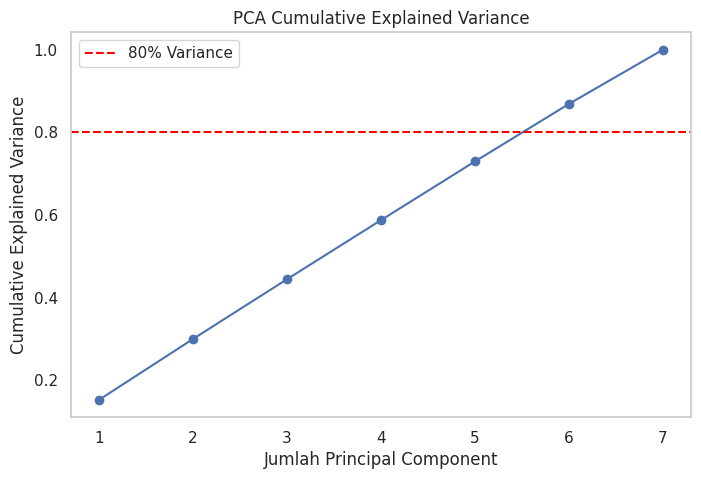

In [ ]:
# PCA untuk melihat cumulative explained variance

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

# Menghitung akumulasi variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.8,
    color='red',
    linestyle='--',
    label='80% Variance'
)

plt.xlabel("Jumlah Principal Component")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.grid()

plt.show()

### Interpretasi PCA Cumulative Explained Variance

Berdasarkan grafik cumulative explained variance, jumlah principal component yang diperlukan untuk menangkap lebih dari 80% variasi data adalah **6 komponen utama**.

Hal ini terlihat karena pada komponen ke-5, cumulative explained variance masih berada di bawah 80%, sedangkan pada komponen ke-6 nilainya sudah melewati batas 80%.

Dengan demikian, untuk mempertahankan sebagian besar informasi dari data, dibutuhkan **6 principal components**. Namun, untuk tujuan visualisasi, PCA tetap dapat direduksi menjadi **2 komponen utama** agar hasil clustering dapat divisualisasikan dalam bentuk scatter plot 2 dimensi.

In [ ]:
# PCA 2 Dimensi untuk visualisasi cluster

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Explained variance PC1:",
      pca_2d.explained_variance_ratio_[0])

print("Explained variance PC2:",
      pca_2d.explained_variance_ratio_[1])

print("Total variance 2 PC:",
      sum(pca_2d.explained_variance_ratio_)*100, "%")

Explained variance PC1: 0.15285940901987816
Explained variance PC2: 0.14727512772285375
Total variance 2 PC: 30.013453674273194 %


### Interpretasi PCA 2 Dimensi

Hasil reduksi dimensi menggunakan PCA menunjukkan bahwa dua komponen utama (PC1 dan PC2) mampu menjelaskan sekitar 30,01% variasi data.

PC1 menjelaskan sekitar 15,29% variasi data, sedangkan PC2 menjelaskan sekitar 14,73%. Walaupun hanya mempertahankan sebagian informasi, visualisasi dua dimensi tetap digunakan agar pola persebaran cluster dapat diamati secara visual.

Untuk mempertahankan lebih dari 80% informasi data diperlukan lebih banyak principal component, namun PCA 2D tetap bermanfaat untuk melihat hubungan dan pemisahan antar cluster.

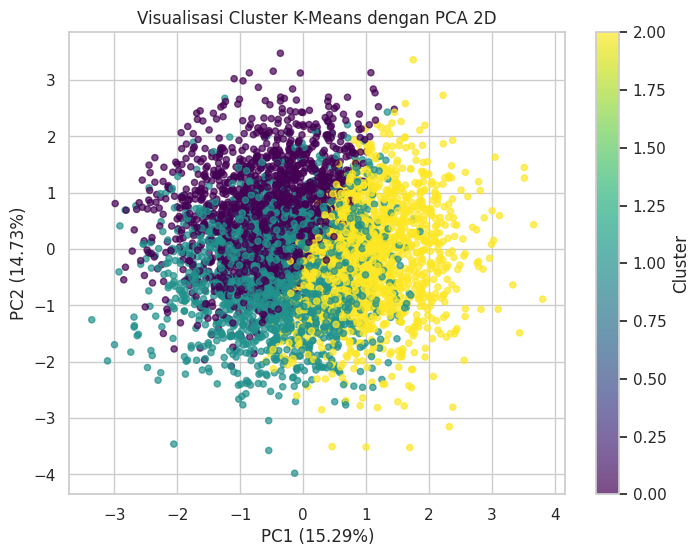

In [ ]:
# Visualisasi PCA 2D untuk K-Means

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    s=20,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Visualisasi Cluster K-Means dengan PCA 2D")

plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

### Interpretasi Visualisasi K-Means dengan PCA 2D

Hasil visualisasi PCA 2D menunjukkan bahwa algoritma K-Means membagi data menjadi tiga cluster. Persebaran cluster terlihat cukup berbeda terutama berdasarkan arah PC1.

Cluster tertentu terlihat lebih terkonsentrasi pada area tertentu, namun masih terdapat overlap antar cluster. Hal ini menunjukkan bahwa beberapa data memiliki karakteristik yang mirip sehingga sulit dipisahkan hanya berdasarkan dua komponen utama PCA.

Visualisasi PCA membantu melihat pola pengelompokan data, meskipun sebagian informasi data hilang karena hanya menggunakan dua komponen utama.

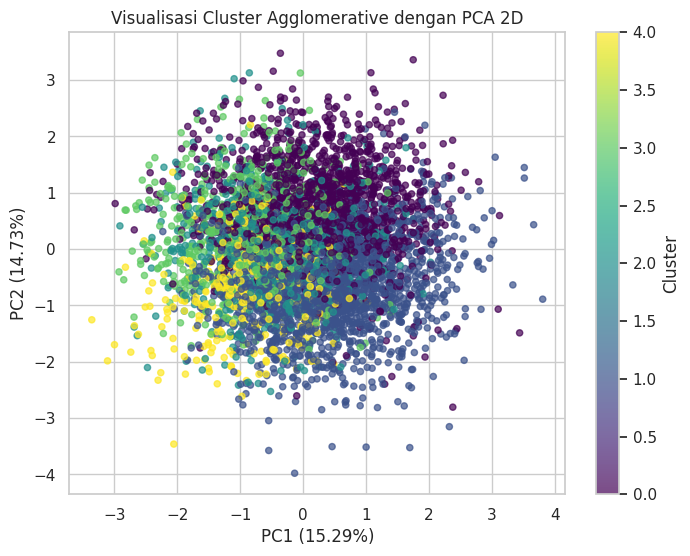

In [ ]:
# Visualisasi PCA 2D untuk Agglomerative

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=agg_labels,
    cmap='viridis',
    s=20,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Visualisasi Cluster Agglomerative dengan PCA 2D")

plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

### Interpretasi Visualisasi Agglomerative dengan PCA 2D

Hasil visualisasi PCA 2D menunjukkan bahwa algoritma Agglomerative menghasilkan beberapa kelompok cluster berdasarkan kemiripan karakteristik data.

Namun, persebaran antar cluster masih mengalami overlap yang cukup besar pada ruang dua dimensi. Hal ini menunjukkan bahwa hubungan antar data lebih kompleks dan tidak seluruh pemisahan cluster dapat terlihat hanya menggunakan dua principal component.

Visualisasi ini memberikan gambaran pola pengelompokan data berdasarkan hasil hierarchical clustering.

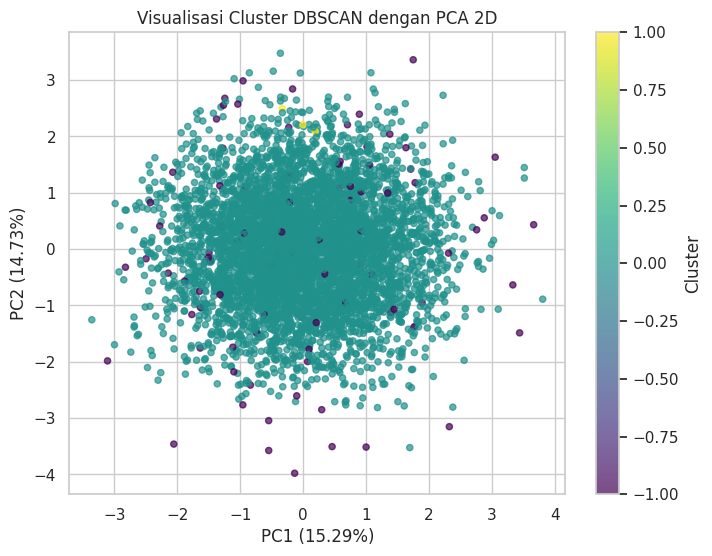

In [ ]:
# Visualisasi PCA 2D untuk DBSCAN

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels_dbscan,
    cmap='viridis',
    s=20,
    alpha=0.7
)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Visualisasi Cluster DBSCAN dengan PCA 2D")

plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

### Interpretasi Visualisasi DBSCAN dengan PCA 2D

Hasil visualisasi PCA 2D menunjukkan bahwa DBSCAN membentuk satu cluster utama dengan beberapa data yang teridentifikasi sebagai noise.

Titik noise terlihat tersebar di beberapa area yang jauh dari kumpulan data utama. Hal ini sesuai dengan karakteristik DBSCAN yang mampu mendeteksi data yang memiliki kepadatan berbeda.

Pada visualisasi dua dimensi, pemisahan cluster DBSCAN tidak terlalu terlihat jelas karena sebagian besar data berada dalam satu area kepadatan yang sama.

# 16. Analisis dan Rekomendasi

## Analisis Perbandingan Hasil Clustering

Berdasarkan hasil evaluasi menggunakan tiga metrik clustering, yaitu Silhouette Score, Davies-Bouldin Index, dan Calinski-Harabasz Index, setiap algoritma menghasilkan karakteristik pengelompokan yang berbeda.

K-Means menghasilkan 3 cluster dengan nilai:
- Silhouette Score: 0.0972
- Davies-Bouldin Index: 2.4671
- Calinski-Harabasz Index: 521.8684

Agglomerative Clustering menghasilkan:
- Silhouette Score: 0.0277
- Davies-Bouldin Index: 2.8378
- Calinski-Harabasz Index: 248.4627

DBSCAN menghasilkan:
- Silhouette Score: 0.1937
- Davies-Bouldin Index: 11.0317
- Calinski-Harabasz Index: 4.8024

Perbedaan nilai evaluasi menunjukkan bahwa masing-masing algoritma memiliki pendekatan berbeda dalam membentuk kelompok data. K-Means membagi data berdasarkan jarak antar titik terhadap pusat cluster, Agglomerative membangun cluster melalui proses penggabungan bertahap, sedangkan DBSCAN mengelompokkan data berdasarkan kepadatan dan mampu mendeteksi data yang dianggap noise.

## Rekomendasi untuk Monitoring Kondisi Mesin

## Rekomendasi untuk Monitoring Kondisi Mesin

Hasil clustering dapat dimanfaatkan sebagai pendekatan awal untuk melakukan monitoring kondisi proses manufaktur.

Data sensor seperti temperatur, tekanan, aliran gas, laju proses, tegangan, dan arus dapat dikelompokkan berdasarkan pola karakteristiknya. Cluster yang memiliki pola berbeda dari kondisi umum dapat menjadi perhatian untuk dilakukan pemeriksaan lebih lanjut oleh teknisi.

Dengan melakukan pemantauan perubahan cluster secara berkala, perusahaan dapat mengetahui adanya perubahan pola operasi mesin lebih awal sebelum terjadi gangguan yang lebih besar.

## Rekomendasi Predictive Maintenance

Hasil clustering dapat menjadi dasar dalam pengembangan sistem predictive maintenance pada mesin manufaktur.

Pola cluster yang terbentuk dari data historis dapat digunakan untuk mengenali kondisi operasi mesin. Jika data baru menunjukkan pola yang berbeda dari cluster normal, sistem dapat memberikan indikasi bahwa mesin perlu diperiksa.

Namun, hasil clustering tidak secara langsung menentukan kerusakan mesin karena algoritma yang digunakan merupakan metode unsupervised learning tanpa label kondisi mesin.

## Keterbatasan Analisis

Meskipun clustering dapat membantu menemukan pola tersembunyi pada data manufaktur, terdapat beberapa keterbatasan dalam analisis ini.

1. **Tidak terdapat label kondisi mesin**
   
   Dataset yang digunakan merupakan data tanpa label untuk proses clustering. Oleh karena itu, hasil cluster tidak dapat langsung dikategorikan sebagai kondisi normal atau abnormal tanpa validasi tambahan dari ahli proses manufaktur.

2. **Hasil bergantung pada preprocessing data**

   Tahapan seperti penanganan missing value, pemilihan fitur, encoding, dan scaling dapat mempengaruhi hasil akhir clustering.

3. **Pemilihan parameter algoritma mempengaruhi hasil**

   Setiap algoritma memiliki parameter yang dapat mengubah hasil pengelompokan. Contohnya jumlah cluster pada K-Means dan parameter eps serta min_samples pada DBSCAN.

4. **Visualisasi PCA hanya menampilkan sebagian informasi**

   PCA 2 dimensi digunakan untuk mempermudah interpretasi visual, tetapi tidak seluruh informasi data dapat terlihat karena data asli memiliki lebih banyak dimensi.